# 03 - Section Based Chunking

## Objective

Create context-preserving chunks aligned with Oracle ERP documentation structure.

Pipeline 2:

- Section-Based Chunking
- BGE-M3 Embeddings
- FAISS
- Qwen3:14B

## Motivation

Oracle documentation is naturally organized into:

- Chapters
- Sections
- Procedures
- Navigation Paths

Instead of creating small fixed-size chunks, this approach creates larger context-preserving sections intended to retain more business meaning.
``

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))


In [2]:
from src.config import DOCS_PATH
from src.loaders.document_loader import DocumentLoader

loader = DocumentLoader(DOCS_PATH)

documents = loader.load()

print(
    f"Source Pages: {len(documents):,}"
)

Starting Document Loading...

Loading PDF : iSupplier_portal.pdf

Loading PDF : Purchasing_manual.pdf


DOCUMENT LOADING SUMMARY
PDF Files Loaded   : 2
DOCX Files Loaded  : 0
XLSX Files Loaded  : 0
Total Documents    : 1502
Source Pages: 1,502


In [3]:
from langchain_core.documents import Document

In [5]:
def create_section_chunks(
    documents,
    target_size=2000
):

    section_chunks = []

    current_text = ""

    current_metadata = None

    for doc in documents:

        page_text = doc.page_content.strip()

        if not page_text:
            continue

        if current_metadata is None:

            current_metadata = doc.metadata.copy()

        current_text += "\n\n" + page_text

        if len(current_text) >= target_size:

            section_chunks.append(
                Document(
                    page_content=current_text.strip(),
                    metadata=current_metadata
                )
            )

            current_text = ""

            current_metadata = None

    if current_text:

        section_chunks.append(
            Document(
                page_content=current_text.strip(),
                metadata=current_metadata
            )
        )

    return section_chunks

In [6]:
section_chunks = create_section_chunks(
    documents,
    target_size=2000
)

print(
    f"Section Chunks Created: {len(section_chunks):,}"
)

Section Chunks Created: 880


In [7]:
section_lengths = [
    len(chunk.page_content)
    for chunk in section_chunks
]


In [8]:
print("=" * 80)

print("SECTION CHUNKING STATISTICS")

print("=" * 80)

print(
    f"Chunk Count     : {len(section_chunks):,}"
)

print(
    f"Minimum Length  : {min(section_lengths):,}"
)

print(
    f"Maximum Length  : {max(section_lengths):,}"
)

print(
    f"Average Length  : {sum(section_lengths)/len(section_lengths):.0f}"
)

SECTION CHUNKING STATISTICS
Chunk Count     : 880
Minimum Length  : 904
Maximum Length  : 5,066
Average Length  : 2830


In [9]:
print("=" * 80)

print("SECTION CHUNK SAMPLE")

print("=" * 80)

print(
    section_chunks[0].page_content[:2500]
)

SECTION CHUNK SAMPLE
Oracle® iSupplier Portal
 User's Guide 
Release 12.2
 Part No. E48972-13
October 2025

Oracle iSupplier Portal User's Guide , Release 12.2
Part No. E48972-13
Copyright © 2009, 2025, Oracle and/or its affiliates. 
Primary Author:     Chetna Arora
Contributing Author:     Gowri Arur, Pragya Nair, Smile Nagpal
This software and related documentation are provided under a license agreement containing restrictions on 
use and disclosure and are protected by intellectual property laws. Except as expressly permitted in your 
license agreement or allowed by law, you may not use, copy, reproduce, translate, broadcast, modify, license, 
transmit, distribute, exhibit, perform, publish, or display any part, in any form, or by any means. Reverse 
engineering, disassembly, or decompilation of this software, unless required by law for interoperability, is 
prohibited. 
The information contained herein is subject to change without notice and is not warranted to be error-free. If 
y

In [10]:
section_chunks[0].metadata

{'source': 'iSupplier_portal.pdf', 'file_type': 'pdf', 'page': 1}

In [11]:
import matplotlib.pyplot as plt

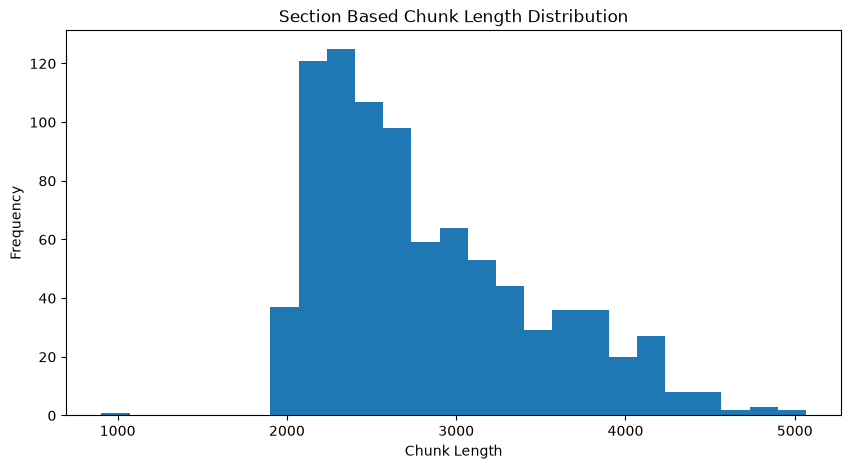

In [12]:
plt.figure(figsize=(10, 5))

plt.hist(
    section_lengths,
    bins=25
)

plt.title(
    "Section Based Chunk Length Distribution"
)

plt.xlabel(
    "Chunk Length"
)

plt.ylabel(
    "Frequency"
)

plt.savefig(
    "../screenshots/chunking/section_chunk_length_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
small_chunks = [
    chunk
    for chunk in section_chunks
    if len(chunk.page_content.strip()) < 50
]

print(
    f"Small Chunks Found: {len(small_chunks)}"
)

Small Chunks Found: 0


In [14]:
for i, chunk in enumerate(
    small_chunks[:10]
):

    print("\n" + "=" * 80)

    print(
        f"SMALL CHUNK #{i+1}"
    )

    print("=" * 80)

    print(
        repr(chunk.page_content)
    )

    print(
        chunk.metadata
    )

# Conclusion

## Section-Based Chunking Results

This strategy creates larger business-context chunks while preserving Oracle ERP procedural information.

### Advantages

- Faster than Semantic Chunking
- CPU Friendly
- Preserves Oracle business context
- Supports large Oracle documentation collections

## Next Step

Proceed to:

### 04_Chunking_Comparison.ipynb